In [18]:
import math
import time
from typing import List, Tuple

import kenlm
import jiwer
import torch
import pandas as pd
import torchaudio
from pathlib import Path
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

### wav2vec2decoder

In [19]:
# ---------------------------------------------------------------------------
# Provided utility — do NOT modify
# ---------------------------------------------------------------------------

def _log_add(a: float, b: float) -> float:
    """Numerically stable log(exp(a) + exp(b))."""
    if a == float('-inf'):
        return b
    if b == float('-inf'):
        return a
    if a > b:
        return a + math.log1p(math.exp(b - a))
    return b + math.log1p(math.exp(a - b))

In [20]:
class Wav2Vec2Decoder:
    def __init__(
            self,
            model_name="facebook/wav2vec2-base-100h",
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=3,
            alpha=1.0,
            beta=1.0,
            temperature=1.0,
        ):
        """
        Args:
            model_name (str): Pretrained Wav2Vec2 model from HuggingFace.
            lm_model_path (str): Path to a KenLM .arpa/.arpa.gz model.
                Pass None to disable LM (Tasks 1–3).
            beam_width (int): Number of hypotheses kept during beam search.
            alpha (float): LM weight used in shallow fusion and rescoring.
                score = log_p_acoustic + alpha * log_p_lm + beta * num_words
            beta (float): Word insertion bonus (see above).
            temperature (float): Scales acoustic logits before softmax.
                T < 1 sharpens the distribution (model more confident).
                T > 1 flattens it (model less confident, giving LM more
                influence). T = 1.0 leaves logits unchanged.
        """
        # Interact with processor/model ONLY here and in decode() to obtain
        # logits — no further model calls are allowed anywhere else.
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2ForCTC.from_pretrained(model_name)

        self.vocab = {i: c for c, i in self.processor.tokenizer.get_vocab().items()}
        self.blank_token_id = self.processor.tokenizer.pad_token_id
        self.word_delimiter = self.processor.tokenizer.word_delimiter_token
        self.beam_width = beam_width
        self.alpha = alpha
        self.beta = beta
        self.temperature = temperature
        self.lm_model = kenlm.Model(lm_model_path) if lm_model_path else None

    # -----------------------------------------------------------------------
    # Provided utility — do NOT modify
    # -----------------------------------------------------------------------

    def _ids_to_text(self, token_ids: List[int]) -> str:
        """Convert a list of token IDs to a decoded string."""
        text = ''.join(self.vocab[i] for i in token_ids)
        return text.replace(self.word_delimiter, ' ').strip().lower()

    # -----------------------------------------------------------------------
    # Tasks 1–4: implement the methods below
    # -----------------------------------------------------------------------

    def greedy_decode(self, logits: torch.Tensor) -> str:
        """
        Perform greedy decoding (find best CTC path).

        Args:
            logits (torch.Tensor): Logits from Wav2Vec2 model (T, V).

        Returns:
            str: Decoded transcript.
        """
        # apply log softmax to get log probabilities
        log_probs = torch.log_softmax(logits, dim=-1)  # (T, V)

        # best token id per frame
        best_ids = torch.argmax(log_probs, dim=-1).tolist()

        # CTC decode: merge repeated tokens and remove blank tokens
        decode = []
        prev = self.blank_token_id
        
        for idx in best_ids:
            if idx == self.blank_token_id:
                prev = idx
                continue
            if idx == prev:
                continue
            decode.append(idx)
            prev = idx

        text = self._ids_to_text(decode)
        return text

    def beam_search_decode(self, logits: torch.Tensor, return_beams: bool = False):
        """
        Perform beam search decoding (no LM).

        Args:
            logits (torch.Tensor): Logits from Wav2Vec2 model (T, V), where
                T - number of time steps and
                V - vocabulary size.
            return_beams (bool): Return all beam hypotheses for second-pass
                LM rescoring.

        Returns:
            Union[str, List[Tuple[List[int], float]]]:
                str - best decoded transcript (if return_beams=False).
                List[Tuple[List[int], float]] - list of (token_ids, log_prob)
                    tuples sorted best-first (if return_beams=True).
        """
        log_probs = torch.log_softmax(logits, dim=-1)  # (T, V)
        T, V = log_probs.shape
        blank = self.blank_token_id

        # Beam state:
        # beams[prefix] = (blank_score, non_blank_score)
        # where prefix is a tuple of token ids (already "collapsed" transcript tokens, no blanks)
        beams = {(): (0.0, float("-inf"))} # empty prefix: blank_score=log(1), non_blank_score=-inf

        def _update(next_beams, prefix, add_blank_score=float("-inf"), add_non_blank_score=float("-inf")):
            """Add log-prob mass into next_beams[prefix]."""
            cur_blank_score, cur_non_blank_score = next_beams.get(prefix, (float("-inf"), float("-inf")))
            if add_blank_score != float("-inf"):
                cur_blank_score = _log_add(cur_blank_score, add_blank_score)
            if add_non_blank_score != float("-inf"):
                cur_non_blank_score = _log_add(cur_non_blank_score, add_non_blank_score)
            next_beams[prefix] = (cur_blank_score, cur_non_blank_score)
        
        for t in range(T):
            next_beams = {}
            frame = log_probs[t].tolist() # length V

            for prefix, (blank_score, non_blank_score) in beams.items():
                total_score = _log_add(blank_score, non_blank_score)
                
                # 1) Emit blank: prefix stays the same, now ends in blank
                _update(next_beams, prefix, add_blank_score=frame[blank] + total_score)
                
                # 2) Emit non-blank symbols
                last = prefix[-1] if prefix else None
                for v in range(V):
                    if v == blank:
                        continue
                    score = frame[v]
                    # same symbol as last
                    if last is not None and v == last:
                        # previous ended non-blank
                        _update(next_beams, prefix, add_non_blank_score=score + non_blank_score)
                        # previous ended blank
                        new_prefix = prefix + (v,)
                        _update(next_beams, new_prefix, add_non_blank_score=score + blank_score)
                    # different symbol will always extends transcript
                    else:
                        new_prefix = prefix + (v,)
                        _update(next_beams, new_prefix, add_non_blank_score=score + total_score)

            # best beam_width prefixes by total score = max(blank_score, non_blank_score)
            beams_sorted = sorted(
                next_beams.items(),
                key=lambda kv: _log_add(kv[1][0], kv[1][1]),
                reverse=True,
            )
            beams = dict(beams_sorted[:self.beam_width])
        
        result = []
        for prefix, (blank_score, non_blank_score) in beams.items():
            result.append((list(prefix), _log_add(blank_score, non_blank_score)))
        result.sort(key=lambda x: x[1], reverse=True)
        
        if return_beams:
            return result
        
        # best hypothesis
        best_ids = result[0][0] if result else []
        text = self._ids_to_text(best_ids)
        return text

    def beam_search_with_lm(self, logits: torch.Tensor) -> str:
        """
        Perform beam search decoding with shallow LM fusion.

        Args:
            logits (torch.Tensor): Logits from Wav2Vec2 model (T, V), where
                T - number of time steps and
                V - vocabulary size.

        Returns:
            str: Decoded transcript.
        """
        if not self.lm_model:
            raise ValueError("KenLM model required for LM shallow fusion")
        
        log_probs = torch.log_softmax(logits, dim=-1)  # (T, V)
        T, V = log_probs.shape
        blank = self.blank_token_id

        # find token id for word delimiter without calling tokenizer.
        delimiter_id = None
        for i, ch in self.vocab.items():
            if ch == self.word_delimiter:
                delimiter_id = i
                break
        if delimiter_id is None:
            raise RuntimeError("Could not find word delimiter token id in vocab.")

        disallowed = {1, 2, 3}  # <s>, </s>, <unk> in KM's vocab list

        # KenLM stateful API: BeginSentenceWrite + BaseScore(word)
        # https://github.com/kpu/kenlm
        use_stateful = hasattr(self.lm_model, "BeginSentenceWrite") and hasattr(self.lm_model, "BaseScore")

        # Beam: (blank_score, non_blank_score, lm_score, word_count, partial_word, lm_state)
        # - lm_score is accumulated word-level LM score (KenLM's native log base; alpha absorbs scaling)
        # - word_count counts completed words (beta)
        if use_stateful:
            init_state = kenlm.State()
            self.lm_model.BeginSentenceWrite(init_state)
        else:
            init_state = None

        beams = {(): (0.0, float("-inf"), 0.0, 0, "", init_state)}

        def combined_score(entry) -> float:
            blank_score, non_blank_score, lm_sc, wc, partial, lm_st = entry
            return _log_add(blank_score, non_blank_score) + (self.alpha * lm_sc) + (self.beta * wc)

        def lm_commit_word(lm_state, lm_score: float, word_count: int, word: str):
            """Advance KenLM with a completed word and return updated (state, score, count)."""
            if not word:
                return lm_state, lm_score, word_count

            if use_stateful:
                out_state = kenlm.State()
                lm_score += self.lm_model.BaseScore(lm_state, word.lower(), out_state)
                lm_state = out_state
            else:
                pass

            word_count += 1
            return lm_state, lm_score, word_count

        def update_next(next_beams, prefix, add_blank_score, add_non_blank_score, meta):
            """
            next_beams[prefix] stores merged acoustic mass; meta is deterministic given prefix
            (lm_score, word_count, partial_word, lm_state).
            """
            if prefix in next_beams:
                blank_score, non_blank_score, lm_sc, wc, partial, st = next_beams[prefix]
                if add_blank_score != float("-inf"):
                    blank_score = _log_add(blank_score, add_blank_score)
                if add_non_blank_score != float("-inf"):
                    non_blank_score = _log_add(non_blank_score, add_non_blank_score)
                next_beams[prefix] = (blank_score, non_blank_score, lm_sc, wc, partial, st)
            else:
                blank_score = add_blank_score
                non_blank_score = add_non_blank_score
                lm_sc, wc, partial, st = meta
                next_beams[prefix] = (blank_score, non_blank_score, lm_sc, wc, partial, st)

        for t in range(T):
            frame = log_probs[t].tolist()
            next_beams = {}

            for prefix, entry in beams.items():
                blank_score, non_blank_score, lm_sc, wc, partial, lm_state = entry
                total_acoustic = _log_add(blank_score, non_blank_score)

                # 1) blank: prefix unchanged, ends in blank
                update_next(next_beams, prefix, add_blank_score=frame[blank] + total_acoustic, 
                            add_non_blank_score=float("-inf"), 
                            meta=(lm_sc, wc, partial, lm_state),
                )

                last = prefix[-1] if prefix else None

                # 2) any non-blank symbol
                for v in range(V):
                    if v == blank or v in disallowed:
                        continue
                    score = frame[v]
                    # repeat char:
                    # (a) keep same prefix if prior was non-blank
                    # (b) extend if prior ended with blank
                    if last is not None and v == last:
                        # (a) stay same prefix
                        update_next(next_beams, prefix, add_blank_score=float("-inf"),
                            add_non_blank_score=score + non_blank_score,
                            meta=(lm_sc, wc, partial, lm_state),
                        )

                        # (b) extend if previous ended blank
                        new_prefix = prefix + (v,)
                        # update LM metadata only if prefix truly extends
                        if v == delimiter_id:
                            new_state, new_lm_sc, new_wc = lm_commit_word(lm_state, lm_sc, wc, partial)
                            new_partial = ""
                        else:
                            new_state, new_lm_sc, new_wc = lm_state, lm_sc, wc
                            new_partial = partial + self.vocab[v]

                        update_next(next_beams, new_prefix, add_blank_score=float("-inf"),
                            add_non_blank_score=score + blank_score,
                            meta=(new_lm_sc, new_wc, new_partial, new_state),
                        )
                    else:
                        # different char: always extends
                        new_prefix = prefix + (v,)
                        if v == delimiter_id:
                            new_state, new_lm_sc, new_wc = lm_commit_word(lm_state, lm_sc, wc, partial)
                            new_partial = ""
                        else:
                            new_state, new_lm_sc, new_wc = lm_state, lm_sc, wc
                            new_partial = partial + self.vocab[v]

                        update_next(next_beams, new_prefix, add_blank_score=float("-inf"),
                            add_non_blank_score=score + total_acoustic,
                            meta=(new_lm_sc, new_wc, new_partial, new_state),
                        )

            # prune by combined (acoustic + alpha*LM + beta*words)
            beams_sorted = sorted(next_beams.items(), key=lambda kv: combined_score(kv[1]), reverse=True)
            beams = dict(beams_sorted[: self.beam_width])

        # score any trailing partial word + end-of-sentence
        best_text = ""
        best_score = float("-inf")

        for prefix, entry in beams.items():
            blank_score, non_blank_score, lm_sc, wc, partial, lm_state = entry
            ac = _log_add(blank_score, non_blank_score)

            if use_stateful:
                # final partial word
                lm_state2, lm_sc2, wc2 = lm_commit_word(lm_state, lm_sc, wc, partial)

                # Add end-of-sentence
                eos_state = kenlm.State()
                lm_sc2 += self.lm_model.BaseScore(lm_state2, "</s>", eos_state)
                final_lm_sc, final_wc = lm_sc2, wc2
            else:
                # Slow fallback: compute LM score on full string
                text = self._ids_to_text(list(prefix))
                # kenlm.Model.score defaults to bos = True and eos = True (https://gitee.com/rhythmblue/kenlm/blob/master/python/example.py)
                final_lm_sc = self.lm_model.score(text, bos=True, eos=True)
                final_wc = len(text.split())

            total = ac + (self.alpha * final_lm_sc) + (self.beta * final_wc)

            if total > best_score:
                best_score = total
                best_text = self._ids_to_text(list(prefix))

        best_text = " ".join(best_text.split())
        return best_text

    def lm_rescore(self, beams: List[Tuple[List[int], float]]) -> str:
        """
        Perform second-pass LM rescoring on beam search outputs.

        Args:
            beams (List[Tuple[List[int], float]]): List of (token_ids, log_prob)
                tuples from beam_search_decode(logits, return_beams=True).

        Returns:
            str: Best rescored transcript.
        """
        if not self.lm_model:
            raise ValueError("KenLM model required for LM rescoring")
        
        best_text = ""
        best_score = float("-inf")

        for token_ids, am_score in beams:
            text = self._ids_to_text(token_ids)
            num_words = 0 if not text else len(text.split())

            lm_score = self.lm_model.score(text, bos=True, eos=True)

            total = am_score + (self.alpha * lm_score) + (self.beta * num_words)

            if total > best_score:
                best_score = total
                best_text = text

        return best_text

    # -----------------------------------------------------------------------
    # Provided — do NOT modify
    # -----------------------------------------------------------------------

    def decode(self, audio_input: torch.Tensor, method: str = "greedy") -> str:
        """
        Run the full decoding pipeline on a raw audio tensor.

        Args:
            audio_input (torch.Tensor): 1-D or 2-D audio waveform at 16 kHz.
            method (str): One of "greedy", "beam", "beam_lm", "beam_lm_rescore".

        Returns:
            str: Decoded transcript (lowercase).
        """
        inputs = self.processor(audio_input, return_tensors="pt", sampling_rate=16000)
        with torch.no_grad():
            logits = self.model(inputs.input_values.squeeze(0)).logits[0]

        # Temperature scaling (Task 3): flatten/sharpen the distribution
        # before log_softmax.  T=1.0 is a no-op.  Your decoders must call
        # torch.log_softmax on the logits they receive — do not call it here.
        logits = logits / self.temperature

        if method == "greedy":
            return self.greedy_decode(logits)
        elif method == "beam":
            return self.beam_search_decode(logits)
        elif method == "beam_lm":
            return self.beam_search_with_lm(logits)
        elif method == "beam_lm_rescore":
            beams = self.beam_search_decode(logits, return_beams=True)
            return self.lm_rescore(beams)
        else:
            raise ValueError(
                f"Unknown method '{method}'. "
                "Choose one of: 'greedy', 'beam', 'beam_lm', 'beam_lm_rescore'."
            )

#### Debug helper

In [4]:
# ---------------------------------------------------------------------------
# Quick debug helper — run this file directly to sanity-check your decoder
# on the provided examples/ clips before evaluating on the full test sets.
# ---------------------------------------------------------------------------

def test(decoder: Wav2Vec2Decoder, audio_path: str, reference: str) -> None:
    import jiwer

    audio_input, sr = torchaudio.load(audio_path)
    assert sr == 16000, f"Expected 16 kHz, got {sr} Hz for {audio_path}"

    print("=" * 60)
    print(f"REF : {reference}")

    for method in ["greedy", "beam", "beam_lm", "beam_lm_rescore"]:
        try:
            hyp = decoder.decode(audio_input, method=method)
        except NotImplementedError:
            print(f"  [{method}] not yet implemented")
            continue
        except ValueError as e:
            print(f"  [{method}] skipped ({e})")
            continue
        cer = jiwer.cer(reference, hyp)
        wer = jiwer.wer(reference, hyp)
        print(f"  [{method}] {hyp}")
        print(f"           WER={wer:.2%}  CER={cer:.2%}")

In [5]:
# ---------------------------------------------------------------------------
# Reference transcripts are lowercase to match the evaluation manifests.
# examples/ clips are for quick debugging only — use data/librispeech_test_other/
# and data/earnings22_test/ for all reported metrics.
# ---------------------------------------------------------------------------

test_samples = [
        ("examples/sample1.wav", "if you are generous here is a fitting opportunity for the exercise of your magnanimity if you are proud here am i your rival ready to acknowledge myself your debtor for an act of the most noble forbearance"),
        ("examples/sample2.wav", "and if any of the other cops had private rackets of their own izzy was undoubtedly the man to find it out and use the information with a beat such as that even going halves and with all the graft to the upper brackets he'd still be able to make his pile in a matter of months"),
        ("examples/sample3.wav", "guess a man gets used to anything hell maybe i can hire some bums to sit around and whoop it up when the ships come in and bill this as a real old martian den of sin"),
        ("examples/sample4.wav", "it was a tune they had all heard hundreds of times so there was no difficulty in turning out a passable imitation of it to the improvised strains of i didn't want to do it the prisoner strode forth to freedom"),
        ("examples/sample5.wav", "marguerite tired out with this long confession threw herself back on the sofa and to stifle a slight cough put up her handkerchief to her lips and from that to her eyes"),
        ("examples/sample6.wav", "at this time all participants are in a listen only mode"),
        ("examples/sample7.wav", "the increase was mainly attributable to the net increase in the average size of our fleets"),
        ("examples/sample8.wav", "operating surplus is a non cap financial measure which is defined as fully in our press release"),
    ]

In [ ]:
# decoder = Wav2Vec2Decoder(lm_model_path=None)  # set lm_model_path for Tasks 4+

# for audio_path, reference in test_samples:
#     test(decoder, audio_path, reference)

In [19]:
decoder = Wav2Vec2Decoder(lm_model_path='./lm/3-gram.pruned.1e-7.arpa.gz')  # set lm_model_path for Tasks 4+

for audio_path, reference in test_samples:
    test(decoder, audio_path, reference)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 45926.99it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


REF : if you are generous here is a fitting opportunity for the exercise of your magnanimity if you are proud here am i your rival ready to acknowledge myself your debtor for an act of the most noble forbearance
  [greedy] if you are generous here is a fiting opportunity for the exercise of your menanimiti if you are proud here am i ar rival rather toknowledge myself your diptor for a act of the most noble forbarans
           WER=23.68%  CER=10.24%
  [beam] if you are generous here is a fiting opportunity for the exercise of your menanimity if you are proud here am i ar rival rather toknowledge myself your diptor for an act of the most noble forbarans
           WER=21.05%  CER=9.27%
  [beam_lm] if you are generous here is a fiting opportunity for the exercise of your menanimity if you are proud here am i ar rival rather toknowledge myself your diptor for an act of the most noble forbarans
           WER=21.05%  CER=9.27%
  [beam_lm_rescore] if you are generous here is a fiting opport

### (Task 2) Eval CTC beam search decoding no LM

In [8]:
import csv

In [9]:
def load_pairs_from_dir(root: str):
    """
    - expects audio: <utt_id>.wav
    - expects transcript: manifest.csv (two columns: path, text
    example manifest row: `data/librispeech_test_other/sample_0.wav, i am from the cutter lying off the coast`
    """
    root = Path(root)
    manifest_path = root / "manifest.csv"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Manifest file not found: {manifest_path}")

    pairs = []
    with open(manifest_path, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) < 2:
                continue 
            audio_rel = row[0].strip()
            text = row[1].strip()
            pairs.append((str(audio_rel), text))
    return pairs

In [49]:
def eval_dir(decoder, root: str, method: str):
    pairs = load_pairs_from_dir(root)[1::]
    print(pairs)
    wers, cers = [], []
    t0 = time.time()

    for wav_path, ref in pairs:
        audio, sr = torchaudio.load(wav_path)
        assert sr == 16000
        hyp = decoder.decode(audio, method=method)

        wers.append(jiwer.wer(ref, hyp))
        cers.append(jiwer.cer(ref, hyp))

    dt = time.time() - t0
    return {
        "n": len(pairs),
        "wer": sum(wers) / max(1, len(wers)),
        "cer": sum(cers) / max(1, len(cers)),
        "sec_total": dt,
        "sec_per_utt": dt / max(1, len(pairs)),
    }

In [50]:
def beam_width_sweep(root="data/librispeech_test_other/"):
    rows = []
    for bw in [1, 3, 10, 50]:
        dec = Wav2Vec2Decoder(lm_model_path=None, beam_width=bw)
        metrics = eval_dir(dec, root, method="beam")
        metrics["beam_width"] = bw
        rows.append(metrics)

    df = pd.DataFrame(rows).sort_values("beam_width")
    print(df[["beam_width", "n", "wer", "cer", "sec_per_utt"]])
    return df

In [7]:
import matplotlib.pyplot as plt

In [52]:
df = beam_width_sweep("data/librispeech_test_other/")

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 36352.92it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[('data/librispeech_test_other/sample_0.wav', 'i am from the cutter lying off the coast'), ('data/librispeech_test_other/sample_1.wav', "don't cry he said i was obliged to come"), ('data/librispeech_test_other/sample_2.wav', 'and and you have not found out anything came in quick frightened tones'), ('data/librispeech_test_other/sample_3.wav', 'i wish you would believe me that i am in as great trouble about it as you are'), ('data/librispeech_test_other/sample_4.wav', 'that my father sir risdon graeme has smuggled goods here'), ('data/librispeech_test_other/sample_5.wav', 'he could not help it he hates the smugglers you shall not tell'), ('data/librispeech_test_other/sample_6.wav', 'pray pray say you will not archy was silent'), ('data/librispeech_test_other/sample_7.wav', 'then as archy stood in the dark literally aghast with astonishment he heard the faint rustling once more and again all was silent'), ('data/librispeech_test_other/sample_8.wav', 'he laughed but it was a curious kind 

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 25147.56it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[('data/librispeech_test_other/sample_0.wav', 'i am from the cutter lying off the coast'), ('data/librispeech_test_other/sample_1.wav', "don't cry he said i was obliged to come"), ('data/librispeech_test_other/sample_2.wav', 'and and you have not found out anything came in quick frightened tones'), ('data/librispeech_test_other/sample_3.wav', 'i wish you would believe me that i am in as great trouble about it as you are'), ('data/librispeech_test_other/sample_4.wav', 'that my father sir risdon graeme has smuggled goods here'), ('data/librispeech_test_other/sample_5.wav', 'he could not help it he hates the smugglers you shall not tell'), ('data/librispeech_test_other/sample_6.wav', 'pray pray say you will not archy was silent'), ('data/librispeech_test_other/sample_7.wav', 'then as archy stood in the dark literally aghast with astonishment he heard the faint rustling once more and again all was silent'), ('data/librispeech_test_other/sample_8.wav', 'he laughed but it was a curious kind 

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 37873.43it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[('data/librispeech_test_other/sample_0.wav', 'i am from the cutter lying off the coast'), ('data/librispeech_test_other/sample_1.wav', "don't cry he said i was obliged to come"), ('data/librispeech_test_other/sample_2.wav', 'and and you have not found out anything came in quick frightened tones'), ('data/librispeech_test_other/sample_3.wav', 'i wish you would believe me that i am in as great trouble about it as you are'), ('data/librispeech_test_other/sample_4.wav', 'that my father sir risdon graeme has smuggled goods here'), ('data/librispeech_test_other/sample_5.wav', 'he could not help it he hates the smugglers you shall not tell'), ('data/librispeech_test_other/sample_6.wav', 'pray pray say you will not archy was silent'), ('data/librispeech_test_other/sample_7.wav', 'then as archy stood in the dark literally aghast with astonishment he heard the faint rustling once more and again all was silent'), ('data/librispeech_test_other/sample_8.wav', 'he laughed but it was a curious kind 

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 33064.09it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[('data/librispeech_test_other/sample_0.wav', 'i am from the cutter lying off the coast'), ('data/librispeech_test_other/sample_1.wav', "don't cry he said i was obliged to come"), ('data/librispeech_test_other/sample_2.wav', 'and and you have not found out anything came in quick frightened tones'), ('data/librispeech_test_other/sample_3.wav', 'i wish you would believe me that i am in as great trouble about it as you are'), ('data/librispeech_test_other/sample_4.wav', 'that my father sir risdon graeme has smuggled goods here'), ('data/librispeech_test_other/sample_5.wav', 'he could not help it he hates the smugglers you shall not tell'), ('data/librispeech_test_other/sample_6.wav', 'pray pray say you will not archy was silent'), ('data/librispeech_test_other/sample_7.wav', 'then as archy stood in the dark literally aghast with astonishment he heard the faint rustling once more and again all was silent'), ('data/librispeech_test_other/sample_8.wav', 'he laughed but it was a curious kind 

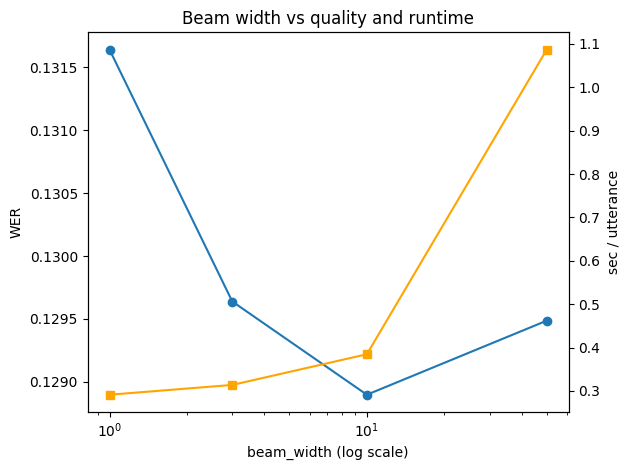

In [53]:
fig, ax1 = plt.subplots()
ax1.plot(df["beam_width"], df["wer"], marker="o")
ax1.set_xscale("log")
ax1.set_xlabel("beam_width (log scale)")
ax1.set_ylabel("WER")

ax2 = ax1.twinx()
ax2.plot(df["beam_width"], df["sec_per_utt"], marker="s", color="orange")
ax2.set_ylabel("sec / utterance")

plt.title("Beam width vs quality and runtime")
plt.tight_layout()
plt.show()

### (Task 3) Eval Temperature scaling sweep

In [59]:
TEMPS = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]

In [54]:
TEMPS = [0.5, ]

In [60]:
def eval_greedy_with_temp(root: str, T: float):
    decoder = Wav2Vec2Decoder(lm_model_path=None, beam_width=1, temperature=T)

    pairs = load_pairs_from_dir(root)[1::]
    wers, cers = [], []

    t0 = time.time()
    for wav_path, ref in pairs:
        audio, sr = torchaudio.load(wav_path)
        assert sr == 16000
        hyp = decoder.decode(audio, method="greedy")
        wers.append(jiwer.wer(ref, hyp))
        cers.append(jiwer.cer(ref, hyp))
    dt = time.time() - t0

    return {
        "T": T,
        "n": len(pairs),
        "WER": sum(wers) / max(1, len(wers)),
        "CER": sum(cers) / max(1, len(cers)),
        "sec_per_utt": dt / max(1, len(pairs)),
    }

In [61]:
def run_temp_sweep():
    rows = [eval_greedy_with_temp("data/librispeech_test_other/", T) for T in TEMPS]
    df = pd.DataFrame(rows).sort_values("T")
    print(df[["T", "n", "WER", "CER", "sec_per_utt"]])
    return df

In [62]:
df = run_temp_sweep()

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 30093.15it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 46345.90it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

     T    n       WER       CER  sec_per_utt
0  0.5  200  0.131532  0.047071     0.262189
1  0.8  200  0.131532  0.047071     0.271984
2  1.0  200  0.131532  0.047071     0.259294
3  1.2  200  0.131532  0.047071     0.254060
4  1.5  200  0.131532  0.047071     0.271980
5  2.0  200  0.131532  0.047071     0.274723


### (Task 4) Eval Beam search with LM 

#### grid sweep + table

In [6]:
import itertools

In [64]:
ALPHAS = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
BETAS  = [0.0, 0.5, 1.0, 1.5]

In [10]:
def eval_set(decoder, pairs, method="beam_lm"):
    wers, cers = [], []
    for wav_path, ref in pairs:
        audio, sr = torchaudio.load(wav_path)
        assert sr == 16000
        hyp = decoder.decode(audio, method=method)
        wers.append(jiwer.wer(ref, hyp))
        cers.append(jiwer.cer(ref, hyp))
    return sum(wers)/len(wers), sum(cers)/len(cers)

In [66]:
def sweep_lm_params():
    pairs = load_pairs_from_dir("data/librispeech_test_other/")[1::]

    rows = []
    for a, b in itertools.product(ALPHAS, BETAS):
        dec = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=50,
            alpha=a,
            beta=b,
        )
        wer, cer = eval_set(dec, pairs, method="beam_lm")
        rows.append({"alpha": a, "beta": b, "WER": wer, "CER": cer})
        print(f"alpha={a:<4} beta={b:<3} WER={wer:.4f} CER={cer:.4f}")

    df = pd.DataFrame(rows)
    return df

In [67]:
df = sweep_lm_params()

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 37055.86it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


alpha=0.01 beta=0.0 WER=0.1295 CER=0.0464


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 41970.76it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


alpha=0.01 beta=0.5 WER=0.1290 CER=0.0463


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 44019.43it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


...

alpha=5.0  beta=0.5 WER=0.2342 CER=0.0691


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 38254.71it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


alpha=5.0  beta=1.0 WER=0.2179 CER=0.0659


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 44497.45it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


alpha=5.0  beta=1.5 WER=0.1993 CER=0.0619


In [68]:
wer_tbl = df.pivot(index="alpha", columns="beta", values="WER")
cer_tbl = df.pivot(index="alpha", columns="beta", values="CER")
print("WER table:\n", wer_tbl)
print("CER table:\n", cer_tbl)

best = df.sort_values("WER").iloc[0]
print("BEST:", best.to_dict())

WER table:
 beta        0.0       0.5       1.0       1.5
alpha                                        
0.01   0.129486  0.129026  0.132497  0.133537
0.05   0.129713  0.128917  0.132497  0.133537
0.10   0.129549  0.128917  0.132529  0.133537
0.50   0.130852  0.128949  0.131450  0.132798
1.00   0.133551  0.130332  0.128637  0.131405
2.00   0.136572  0.135814  0.131408  0.129505
5.00   0.287104  0.234156  0.217883  0.199256
CER table:
 beta        0.0       0.5       1.0       1.5
alpha                                        
0.01   0.046449  0.046291  0.046548  0.046602
0.05   0.046504  0.046269  0.046548  0.046602
0.10   0.046487  0.046269  0.046508  0.046602
0.50   0.046675  0.046390  0.046401  0.046607
1.00   0.047155  0.046633  0.046180  0.046370
2.00   0.048069  0.047887  0.046875  0.046390
5.00   0.079921  0.069144  0.065944  0.061928
BEST: {'alpha': 1.0, 'beta': 1.0, 'WER': 0.12863698440124027, 'CER': 0.046179674255298765}


### (Task 5) Eval OpenSLR 4‑gram KenLM

In [70]:
pairs = load_pairs_from_dir("data/librispeech_test_other/")[1::]

BEST_ALPHA = 1.0   # <- replace with your Task 4 best
BEST_BETA  = 1.0   # <- replace with your Task 4 best
BEAM_WIDTH = 50

configs = [
    ("3-gram pruned", "lm/3-gram.pruned.1e-7.arpa.gz"),
    ("4-gram",        "lm/4-gram.arpa.gz"),
]

In [ ]:
rows = []
for name, lm_path in configs:
    dec = Wav2Vec2Decoder(
        lm_model_path=lm_path,
        beam_width=BEAM_WIDTH,
        alpha=BEST_ALPHA,
        beta=BEST_BETA,
    )
    wer, cer = eval_set(dec, pairs, method="beam_lm")
    rows.append((name, wer, cer))
    print(name, "WER", wer, "CER", cer)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 34438.13it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


3-gram pruned WER 0.12863698440124027 CER 0.046179674255298765


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 33682.81it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/4-gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


4-gram WER 0.12958772102438712 CER 0.04634903206610881


In [72]:
print("\nSummary:")
for name, wer, cer in rows:
    print(f"{name:12s}  WER={wer:.4%}  CER={cer:.4%}")


Summary:
3-gram pruned  WER=12.8637%  CER=4.6180%
4-gram        WER=12.9588%  CER=4.6349%


### (Task 6) Eval alpha/beta sweep for rescoring + compare to shallow fusion 

In [92]:
ALPHAS = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
BETAS  = [0.0, 0.5, 1.0, 1.5]

In [93]:
def sweep_rescore():
    pairs = load_pairs_from_dir("data/librispeech_test_other/")[1::]

    rows = []
    for a, b in itertools.product(ALPHAS, BETAS):
        dec = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=50,   # first-pass beam width (also controls N-best size returned)
            alpha=a,
            beta=b,
        )
        wer, cer = eval_set(dec, pairs, method="beam_lm_rescore")
        rows.append({"alpha": a, "beta": b, "WER": wer, "CER": cer})
        print(f"[RS] alpha={a:<4} beta={b:<3} WER={wer:.4f} CER={cer:.4f}")

    df = pd.DataFrame(rows)
    wer_tbl = df.pivot(index="alpha", columns="beta", values="WER")
    cer_tbl = df.pivot(index="alpha", columns="beta", values="CER")

    print("\nWER pivot:\n", wer_tbl)
    print("\nCER pivot:\n", cer_tbl)

    best = df.sort_values("WER").iloc[0].to_dict()
    print("\nBEST (rescoring):", best)
    return df, wer_tbl, cer_tbl

In [94]:
df, wer_tbl, cer_tbl = sweep_rescore()

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 32121.68it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


[RS] alpha=0.01 beta=0.0 WER=0.1295 CER=0.0464


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 39421.55it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


[RS] alpha=0.01 beta=0.5 WER=0.1281 CER=0.0461


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 43147.93it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


...

[RS] alpha=5.0  beta=0.5 WER=0.1496 CER=0.0496


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 42117.87it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


[RS] alpha=5.0  beta=1.0 WER=0.1453 CER=0.0489


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 23852.37it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


[RS] alpha=5.0  beta=1.5 WER=0.1427 CER=0.0484

WER pivot:
 beta        0.0       0.5       1.0       1.5
alpha                                        
0.01   0.129486  0.128132  0.132017  0.133701
0.05   0.129486  0.128132  0.132017  0.133701
0.10   0.129322  0.128132  0.131678  0.133545
0.50   0.130768  0.128949  0.131643  0.132072
1.00   0.133031  0.130104  0.128324  0.130974
2.00   0.135869  0.133325  0.130768  0.128949
5.00   0.155105  0.149570  0.145345  0.142687

CER pivot:
 beta        0.0       0.5       1.0       1.5
alpha                                        
0.01   0.046449  0.046078  0.046470  0.046659
0.05   0.046449  0.046078  0.046470  0.046659
0.10   0.046432  0.046078  0.046434  0.046632
0.50   0.046648  0.046390  0.046406  0.046491
1.00   0.047080  0.046578  0.046113  0.046303
2.00   0.047606  0.047142  0.046648  0.046390
5.00   0.050143  0.049591  0.048864  0.048410

BEST (rescoring): {'alpha': 0.01, 'beta': 0.5, 'WER': 0.12813217670893257, 'CER': 0.04607828536640

#### find utterances where LM changes hypothesis

In [11]:
import random

In [12]:
def mine_examples(
    data_root="data/librispeech_test_other/",
    lm_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=50,
    alpha_sf=1.0, beta_sf=1.0,   #  best from Task 4
    alpha_rs=0.01, beta_rs=0.5,   #  best from rescoring sweep
    k=5,
    seed=0,
):
    pairs = load_pairs_from_dir(data_root)[1::]
    random.Random(seed).shuffle(pairs)

    dec_beam = Wav2Vec2Decoder(lm_model_path=None, beam_width=beam_width)
    dec_sf   = Wav2Vec2Decoder(lm_model_path=lm_path, beam_width=beam_width, alpha=alpha_sf, beta=beta_sf)
    dec_rs   = Wav2Vec2Decoder(lm_model_path=lm_path, beam_width=beam_width, alpha=alpha_rs, beta=beta_rs)

    chosen = []
    for wav_path, ref in pairs:
        audio, sr = torchaudio.load(wav_path)
        assert sr == 16000

        hyp_beam = dec_beam.decode(audio, method="beam")
        hyp_sf   = dec_sf.decode(audio, method="beam_lm")
        hyp_rs   = dec_rs.decode(audio, method="beam_lm_rescore")
        # must differ from plain beam for at least one LM method
        if hyp_sf != hyp_beam or hyp_rs != hyp_beam:
            chosen.append((ref, hyp_beam, hyp_sf, hyp_rs, wav_path))
            print(f'current k: {len(chosen)}')

        if len(chosen) >= k:
            break
        

    for ref, beam, sf, rs, wav_path in chosen:
        print("-" * 80)
        print(f"WAV:  {wav_path}")
        print(f"REF:  {ref}")
        print(f"BEAM: {beam}   (WER={jiwer.wer(ref, beam):.2%})")
        print(f"SF:   {sf}   (WER={jiwer.wer(ref, sf):.2%})")
        print(f"RS:   {rs}   (WER={jiwer.wer(ref, rs):.2%})")

    return chosen

In [13]:
mine_examples(k=10)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 37902.49it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 212/212 [00:00<00:00, 24423.67it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

current k: 1
current k: 2
current k: 3
current k: 4
current k: 5
current k: 6
current k: 7
--------------------------------------------------------------------------------
WAV:  data/librispeech_test_other/sample_153.wav
REF:  each that died we washed and shrouded in some of the clothes and linen cast ashore by the tides and after a little the rest of my fellows perished one by one till i had buried the last of the party and abode alone on the island with but a little provision left i who was wont to have so much
BEAM: each that died we washed and shrowded in some of the clothes and linen cast a shore by the tides and after little the rest of my fellows perished one by one till i had buried the last of the party and aboade alone on the island with but a little provision left i who was wont to have so much   (WER=8.20%)
SF:   each that died we washed and shrowded in some of the clothes and linen cast a shore by the tides and after a little the rest of my fellows perished one by one till

[('each that died we washed and shrouded in some of the clothes and linen cast ashore by the tides and after a little the rest of my fellows perished one by one till i had buried the last of the party and abode alone on the island with but a little provision left i who was wont to have so much',
  'each that died we washed and shrowded in some of the clothes and linen cast a shore by the tides and after little the rest of my fellows perished one by one till i had buried the last of the party and aboade alone on the island with but a little provision left i who was wont to have so much',
  'each that died we washed and shrowded in some of the clothes and linen cast a shore by the tides and after a little the rest of my fellows perished one by one till i had buried the last of the party and aboade alone on the island with but a little provision left i who was wont to have so much',
  'each that died we washed and shrowded in some of the clothes and linen cast a shore by the tides and aft

### (Task 7) Evaluate best SF + best RS on Earnings22 and produce 2-dataset comparison table

In [ ]:
def eval_best_sf_best_rs(
    best_sf_alpha: float,
    best_sf_beta: float,
    best_rs_alpha: float,
    best_rs_beta: float,
    beam_width: int = 50,
    lm_path: str = "lm/3-gram.pruned.1e-7.arpa.gz",
    librispeech_root: str = "data/librispeech_test_other/",
    earnings_root: str = "data/earnings22_test/",
    save_csv_path: str = "task7_results.csv",
):
    librispeech_pairs = load_pairs_from_dir(librispeech_root)[1::]
    earnings_pairs = load_pairs_from_dir(earnings_root)[1::]

    decoder = Wav2Vec2Decoder(
        lm_model_path=lm_path,
        beam_width=beam_width,
        alpha=best_sf_alpha,
        beta=best_sf_beta,
        temperature=1.0,
    )

    methods = [
        ("Greedy", "greedy", None),
        ("Beam search", "beam", None),
        ("Beam + 3-gram (shallow fusion)", "beam_lm", (best_sf_alpha, best_sf_beta)),
        ("Beam + 3-gram (rescoring)", "beam_lm_rescore", (best_rs_alpha, best_rs_beta)),
    ]

    rows = []
    for name, method_key, ab in methods:
        if ab is not None:
            decoder.alpha, decoder.beta = ab

        ls_wer, ls_cer = eval_set(decoder, librispeech_pairs, method=method_key)
        ea_wer, ea_cer = eval_set(decoder, earnings_pairs, method=method_key)

        rows.append(
            {
                "Method": name,
                "LibriSpeech WER": ls_wer,
                "LibriSpeech CER": ls_cer,
                "Earnings22 WER": ea_wer,
                "Earnings22 CER": ea_cer,
            }
        )

    df = pd.DataFrame(rows)

    print("\n| Method | LibriSpeech WER | LibriSpeech CER | Earnings22 WER | Earnings22 CER |")
    print("|---|---:|---:|---:|---:|")
    for _, r in df.iterrows():
        print(
            f"| {r['Method']} | {r['LibriSpeech WER']:.4f} | {r['LibriSpeech CER']:.4f} | "
            f"{r['Earnings22 WER']:.4f} | {r['Earnings22 CER']:.4f} |"
        )

    if save_csv_path:
        df.to_csv(save_csv_path, index=False)
        print(f"\nSaved CSV: {save_csv_path}")

    return df

In [ ]:
df_task7 = eval_best_sf_best_rs(
    best_sf_alpha=1.0,
    best_sf_beta=1.0,
    best_rs_alpha=0.01,
    best_rs_beta=0.5,
    beam_width=50,
)
df_task7

LibriSpeech pairs: 200
Earnings22 pairs:  200


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 40265.93it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************



| Method | LibriSpeech WER | LibriSpeech CER | Earnings22 WER | Earnings22 CER |
|---|---:|---:|---:|---:|
| Greedy | 0.1315 | 0.0471 | 0.6231 | 0.3128 |
| Beam search | 0.1295 | 0.0464 | 0.6236 | 0.3120 |
| Beam + 3-gram (shallow fusion) | 0.1286 | 0.0462 | 0.6295 | 0.3114 |
| Beam + 3-gram (rescoring) | 0.1281 | 0.0461 | 0.6298 | 0.3118 |

Saved CSV: task7_results.csv


,Method,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
0,Greedy,0.131532,0.047071,0.623100,0.312810
1,Beam search,0.129486,0.046449,0.623575,0.311958
2,Beam + 3-gram (shallow fusion),0.128637,0.046180,0.629477,0.311382
3,Beam + 3-gram (rescoring),0.128132,0.046078,0.629808,0.311804


### (Task 7b) Temperature sweep on `data/earnings22_test/

In [ ]:
def temperature_sweep_earnings22(
    best_sf_alpha: float,
    best_sf_beta: float,
    beam_width: int = 50,
    lm_path: str = "lm/3-gram.pruned.1e-7.arpa.gz",
    earnings_root: str = "data/earnings22_test/",
    temps = (0.5, 1.0, 1.5, 2.0),
    save_csv_path: str = "task7b_temp_sweep_earnings22.csv",
):
    earnings_pairs = load_pairs_from_dir(earnings_root)[1::]
    print(f"Earnings22 pairs: {len(earnings_pairs)}")

    rows = []

    for T in temps:
        decoder = Wav2Vec2Decoder(
            lm_model_path=lm_path,
            beam_width=beam_width,
            alpha=best_sf_alpha,
            beta=best_sf_beta,
            temperature=T,
        )

        greedy_wer, greedy_cer = eval_set(decoder, earnings_pairs, method="greedy")
        sf_wer, sf_cer = eval_set(decoder, earnings_pairs, method="beam_lm")

        rows.append({
            "T": T,
            "greedy_WER": greedy_wer,
            "greedy_CER": greedy_cer,
            "sf_WER": sf_wer,
            "sf_CER": sf_cer,
        })

        print(
            f"T={T:<3} | greedy WER={greedy_wer:.4f} CER={greedy_cer:.4f} "
            f"| SF WER={sf_wer:.4f} CER={sf_cer:.4f}"
        )

    df = pd.DataFrame(rows).sort_values("T")

    if save_csv_path:
        df.to_csv(save_csv_path, index=False)
        print(f"\nSaved CSV: {save_csv_path}")

    # Plot WER vs T
    plt.figure(figsize=(7, 4))
    plt.plot(df["T"], df["greedy_WER"], marker="o", label="Greedy")
    plt.plot(df["T"], df["sf_WER"], marker="s", label="Beam + LM (shallow fusion)")
    plt.xlabel("Temperature T")
    plt.ylabel("WER")
    plt.title("Earnings22: WER vs Temperature (Greedy vs Shallow Fusion)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df

Earnings22 pairs: 200


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 44992.79it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


T=0.5 | greedy WER=0.6231 CER=0.3128 | SF WER=0.6255 CER=0.3125


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 27549.65it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


T=1.0 | greedy WER=0.6231 CER=0.3128 | SF WER=0.6295 CER=0.3114


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 26595.46it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


T=1.5 | greedy WER=0.6231 CER=0.3128 | SF WER=0.6401 CER=0.3151


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 37612.30it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


T=2.0 | greedy WER=0.6231 CER=0.3128 | SF WER=0.6517 CER=0.3165

Saved CSV: task7b_temp_sweep_earnings22.csv


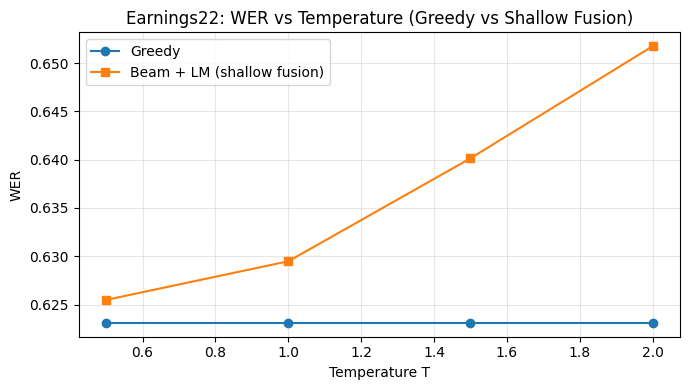

,T,greedy_WER,greedy_CER,sf_WER,sf_CER
0,0.5,0.6231,0.31281,0.625479,0.312458
1,1.0,0.6231,0.31281,0.629477,0.311382
2,1.5,0.6231,0.31281,0.640137,0.315141
3,2.0,0.6231,0.31281,0.651745,0.316484


In [ ]:
df_t7b = temperature_sweep_earnings22(
    best_sf_alpha=1.0,
    best_sf_beta=1.0,
    beam_width=50,
    temps=(0.5, 1.0, 1.5, 2.0),
)
df_t7b

### (Task 8)

```bash
=== 1/5 Counting and sorting n-grams ===
Reading /mnt/e/work/itmo/subjects/speech_course/ai-talent-hub-itmo-speech-course/assignments/assignment2/data/earnings22_train/corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 101181 types 5701
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:68412 2:9352660992 3:17536239616
Statistics:
1 5701 D1=0.568292 D2=1.02526 D3+=1.54415
2 42688 D1=0.761144 D2=1.14769 D3+=1.46089
3 77164 D1=0.868472 D2=1.23411 D3+=1.48545
Memory estimate for binary LM:
type      kB
probing 2501 assuming -p 1.5
probing 2774 assuming -r models -p 1.5
trie    1032 without quantization
trie     574 assuming -q 8 -b 8 quantization 
trie     984 assuming -a 22 array pointer compression
trie     526 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:68412 2:683008 3:1543280
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
####################################################################################################
=== 4/5 Calculating and writing order-interpolated probabilities ===
Chain sizes: 1:68412 2:683008 3:1543280
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
####################################################################################################
=== 5/5 Writing ARPA model ===
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Name:lmplz      VmPeak:26406364 kB      VmRSS:7000 kB   RSSMax:6076416 kB       user:0.431861   sys:5.47697     CPU:5.90891     real:5.82783
```

In [21]:
def eval_lms_libri_earnings22(
    lm_librispeech_path="lm/3-gram.pruned.1e-7.arpa.gz",
    lm_financial_path="lm/financial-3gram.arpa.gz",

    librispeech_root="data/librispeech_test_other/",
    earnings_root="data/earnings22_test/",

    beam_width=50,

    sf_alpha=1.0,
    sf_beta=1.0,
    rs_alpha=0.01,
    rs_beta=0.5,

    save_csv_path="task9_lms_libri_earnings22.csv",
):
    ls_pairs = load_pairs_from_dir(librispeech_root)[1::]
    ea_pairs = load_pairs_from_dir(earnings_root)[1::]

    lm_specs = [
        ("LibriSpeech-3gram", lm_librispeech_path),
        ("Financial-3gram",   lm_financial_path),
    ]

    methods = [
        ("Shallow Fusion", "beam_lm", sf_alpha, sf_beta),
        ("Rescoring",      "beam_lm_rescore", rs_alpha, rs_beta),
    ]

    rows = []

    for lm_name, lm_path in lm_specs:

        decoder = Wav2Vec2Decoder(
            lm_model_path=lm_path,
            beam_width=beam_width,
            alpha=sf_alpha,
            beta=sf_beta,
            temperature=1.0,
        )

        for method_name, method_key, a, b in methods:
            decoder.alpha, decoder.beta = a, b

            ls_wer, ls_cer = eval_set(decoder, ls_pairs, method=method_key)
            ea_wer, ea_cer = eval_set(decoder, ea_pairs, method=method_key)

            rows.append({
                "LM": lm_name,
                "LM_path": lm_path,
                "Method": method_name,
                "beam_width": beam_width,
                "alpha": a,
                "beta": b,
                "LibriSpeech_WER": ls_wer,
                "LibriSpeech_CER": ls_cer,
                "Earnings22_WER": ea_wer,
                "Earnings22_CER": ea_cer,
            })

            print(
                f"{lm_name:16s} | {method_name:13s} | "
                f"LS WER={ls_wer:.4f} CER={ls_cer:.4f} | "
                f"EA WER={ea_wer:.4f} CER={ea_cer:.4f}"
            )

    df = pd.DataFrame(rows)

    report = df[[
        "LM", "Method", "alpha", "beta",
        "LibriSpeech_WER", "LibriSpeech_CER",
        "Earnings22_WER", "Earnings22_CER",
    ]].copy()

    display(report)

    if save_csv_path:
        df.to_csv(save_csv_path, index=False)
        print(f"\nSaved CSV: {save_csv_path}")

    return df

In [22]:
df_task9 = eval_lms_libri_earnings22(
    sf_alpha=1.0, sf_beta=1.0,
    rs_alpha=0.01, rs_beta=0.5,
    beam_width=50,
)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 21909.39it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


LibriSpeech-3gram | Shallow Fusion | LS WER=0.1286 CER=0.0462 | EA WER=0.6295 CER=0.3114
LibriSpeech-3gram | Rescoring     | LS WER=0.1281 CER=0.0461 | EA WER=0.6298 CER=0.3118


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 37663.28it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /mnt/e/work/itmo/subjects/speech_course/itmo-sc-tasks/assignments/n3/lm/financial-3gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Financial-3gram  | Shallow Fusion | LS WER=0.1504 CER=0.0508 | EA WER=0.5576 CER=0.3115
Financial-3gram  | Rescoring     | LS WER=0.1277 CER=0.0460 | EA WER=0.6284 CER=0.3119


,LM,Method,alpha,beta,LibriSpeech_WER,LibriSpeech_CER,Earnings22_WER,Earnings22_CER
0,LibriSpeech-3gram,Shallow Fusion,1.00,1.0,0.128637,0.046180,0.629477,0.311382
1,LibriSpeech-3gram,Rescoring,0.01,0.5,0.128132,0.046078,0.629808,0.311804
2,Financial-3gram,Shallow Fusion,1.00,1.0,0.150389,0.050800,0.557587,0.311531
3,Financial-3gram,Rescoring,0.01,0.5,0.127716,0.046050,0.628423,0.311872



Saved CSV: task9_lms_libri_earnings22.csv


In [27]:
import numpy as np

In [28]:
plot_rows = []
for _, r in df_task9.iterrows():
    plot_rows.append({"Domain": "LibriSpeech", "Metric": "WER", "Value": r["LibriSpeech_WER"], "LM": r["LM"], "Method": r["Method"]})
    plot_rows.append({"Domain": "LibriSpeech", "Metric": "CER", "Value": r["LibriSpeech_CER"], "LM": r["LM"], "Method": r["Method"]})
    plot_rows.append({"Domain": "Earnings22", "Metric": "WER", "Value": r["Earnings22_WER"], "LM": r["LM"], "Method": r["Method"]})
    plot_rows.append({"Domain": "Earnings22", "Metric": "CER", "Value": r["Earnings22_CER"], "LM": r["LM"], "Method": r["Method"]})

dfp = pd.DataFrame(plot_rows)

In [29]:
lm_order = list(dfp["LM"].drop_duplicates())
method_order = ["Shallow Fusion", "Rescoring"]
domain_order = ["LibriSpeech", "Earnings22"]

In [35]:
def _barplot(metric):
        d = dfp[dfp["Metric"] == metric].copy()

        combos = [(m, lm) for m in method_order for lm in lm_order]
        n_bars = len(combos)
        x = np.arange(len(domain_order))
        width = 0.8 / n_bars

        plt.figure(figsize=(10, 4.2))

        for i, (m, lm) in enumerate(combos):
            vals = []
            for dom in domain_order:
                sel = d[(d["Domain"] == dom) & (d["Method"] == m) & (d["LM"] == lm)]
                vals.append(float(sel["Value"].iloc[0]))

            xpos = x - 0.4 + width/2 + i * width
            label = f"{m} + {lm}"
            plt.bar(xpos, vals, width=width, label=label)

        plt.xticks(x, domain_order)
        plt.ylabel(metric)
        plt.title(f"{metric} by domain, LM, and decoding method")
        plt.grid(axis="y", alpha=0.25)
        plt.legend(ncol=2, fontsize=9)
        plt.tight_layout()

        plt.show()

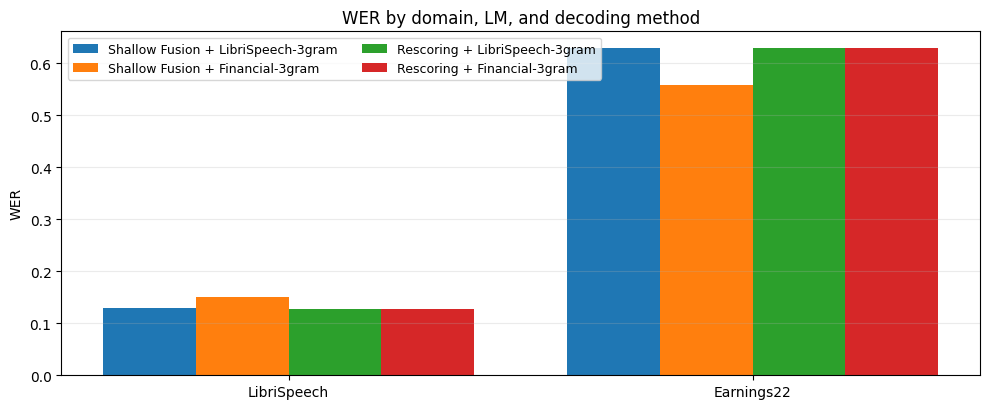

In [36]:
_barplot("WER")

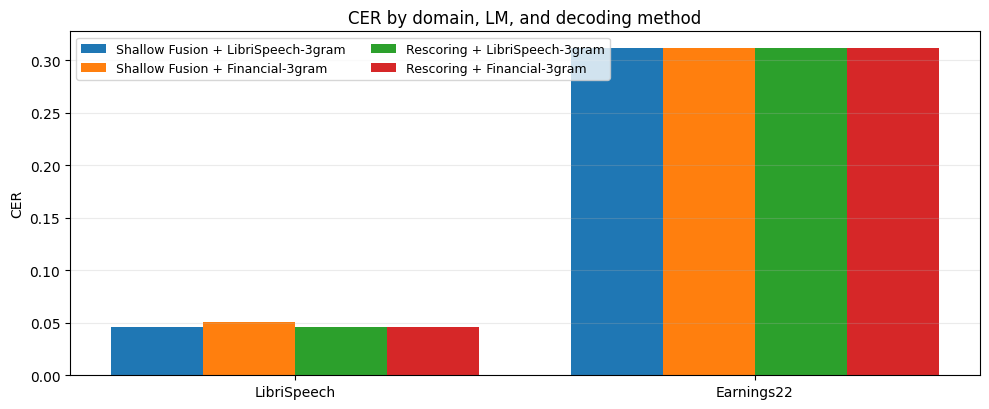

In [37]:
_barplot("CER")